
# Linear Interpolation and Numerical Differentiation



## 1. Linear Interpolation

Linear interpolation estimates unknown values between two known data points using the formula:

$$
y = y_0 + \frac{(x - x_0)(y_1 - y_0)}{x_1 - x_0}
$$


### Exercise- 
Find the linear interpolation value at x = 2.5 between the two unkown data points (1, 3) & (4, 12). Print your results.

In [35]:
# Yor code here to complete the Linear Interpolation Function
def linear_interpolate(x0, y0, x1, y1, x):
    return y0 + (x - x0) * (y1 - y0) / (x1 - x0)
result = linear_interpolate(1, 3, 4, 12, 2.5)

x = 2.5

print(f"The interpolated value at x = {x} is y = {result}")


The interpolated value at x = 2.5 is y = 7.5


In [ ]:
# Yor code here to complete the Linear Interpolation Function
# Example using the numbers given in class.
def linear_interpolate(x0, y0, x1, y1, x):
    return y0 + (x - x0) * (y1 - y0) / (x1 - x0)
result = linear_interpolate(1, 1, 5, 5, 3)

print(f"The interpolated value at x=3 is y={result}")


The interpolated value at x=3 is y=3.0



## 2. Numerical Differentiation

Numerical differentiation estimates the derivative of a function using discrete data points.

- Forward Difference:
$$f'(x) \approx \frac{f(x+h) - f(x)}{h}$$

- Backward Difference:
$$f'(x) \approx \frac{f(x) - f(x-h)}{h}$$

- Central Difference:
$$f'(x) \approx \frac{f(x+h) - f(x-h)}{2h}$$


### Exercise- 
Find the derivative of f = sin (x) at x = pi/4 using foward difference, backward difference, and central difference. You decide the step size.

In [1]:
# Your code here
import math
import matplotlib.pyplot as plt
import numpy as np
from numpy.linalg import matrix_rank, det, solve, lstsq, inv
x = math.pi / 4
h = 0.01


def f(x):
    return math.sin(x)

def numerical_derivative(f, x, h=1e-5):
    return (f(x + h) - f(x - h)) / (2 * h)

derivative_at_x = numerical_derivative(f, x, h)
print(f"The numerical (central) derivative of sin(x) at x = pi/4 is approximately {derivative_at_x:.6f}")
print(f"The exact derivative (cos) at x = pi/4 is {math.cos(x):.6f}")

def forward_difference(f, x, h=1e-5):
    return (f(x + h) - f(x)) / h

def backward_difference(f, x, h=1e-5):
    return (f(x) - f(x - h)) / h

def central_difference(f, x, h=1e-5):
    return (f(x + h) - f(x - h)) / (2 * h)

# compute with chosen h
fd = forward_difference(f, x, h)
bd = backward_difference(f, x, h)
cd = central_difference(f, x, h)

print(f"Forward difference:  {fd:.6f}")
print(f"Backward difference: {bd:.6f}")
print(f"Central difference:  {cd:.6f}")



The numerical (central) derivative of sin(x) at x = pi/4 is approximately 0.707095
The exact derivative (cos) at x = pi/4 is 0.707107
Forward difference:  0.703559
Backward difference: 0.710631
Central difference:  0.707095



## 3. Numerical Differentiation Using Taylor Series

Implement numerical differentiation formulas for higher-order derivatives using Taylor series expansions. 


### Exercise- 
Usign Taylor series, compute the first to fourth derivatives of the function f(x) = sin(x) and plot them from x= 0 to x= 2(pi). 

In [6]:
# Your code here
import math
import numpy as np
from numpy.linalg import matrix_rank, det, solve, lstsq, inv
import matplotlib.pyplot as plt
np.set_printoptions(suppress=True, precision=4)

np.linspace(0, 2*math.pi, 101)
h = 0.01

def f(x):
    return np.sin(x)

def first_derivative(f, x, h):
    return (f(x + h) - f(x)) / (h)

def second_derivative(f, x, h):
    return (f(x + h) - 2 * f(x) + f(x - h)) / (h**2)

def third_derivative(f, x, h):
    return (f(x + 2*h) - 2 * f(x + h) + 2 * f(x - h) - f(x - 2 * h)) / (2 * h**3)

def fourth_derivative(f, x, h):
    return (f(x + 2*h) - 4 * f(x + h) + 6 * f(x) - 4 * f(x - h) + f(x - 2 * h)) / (h**4)


print("First Derivative:", first_derivative(f, math.pi / 4, h))
print("Second Derivative:", second_derivative(f, math.pi / 4, h))
print("Third Derivative:", third_derivative(f, math.pi / 4, h))
print("Fourth Derivative:", fourth_derivative(f, math.pi / 4, h))


# the linspace step sizes need to match your points.


First Derivative: 0.7035594916892096
Second Derivative: -0.7071008886483376
Third Derivative: -0.7070891036575765
Fourth Derivative: 0.707094949259357


### Engineering Problem: Beam Deflection Analysis

A simply supported beam of length (L = 10m ) is subjected to a uniformly distributed load w = 5 kN/m. The deflection y(x) of the beam at a distance x from the left support is given by:

$$
y(x) = \frac{w}{24EI} \, x \left( L^3 - 2Lx^2 + x^3 \right)
$$


#### 🎯 Task:
Given deflection data y(x) along a beam, estimate the bending moment M(x) and shear force V(x) using numerical differentiation and plot them. 

Equations:
$$ M(x) = -EI \frac{d^2 y}{dx^2}$$
$$ V(x) = \frac{dM}{dx} $$

#### 📌 Constants:
- L = 10 
- w = 5 
- E = 200e9
- I = 1e-6

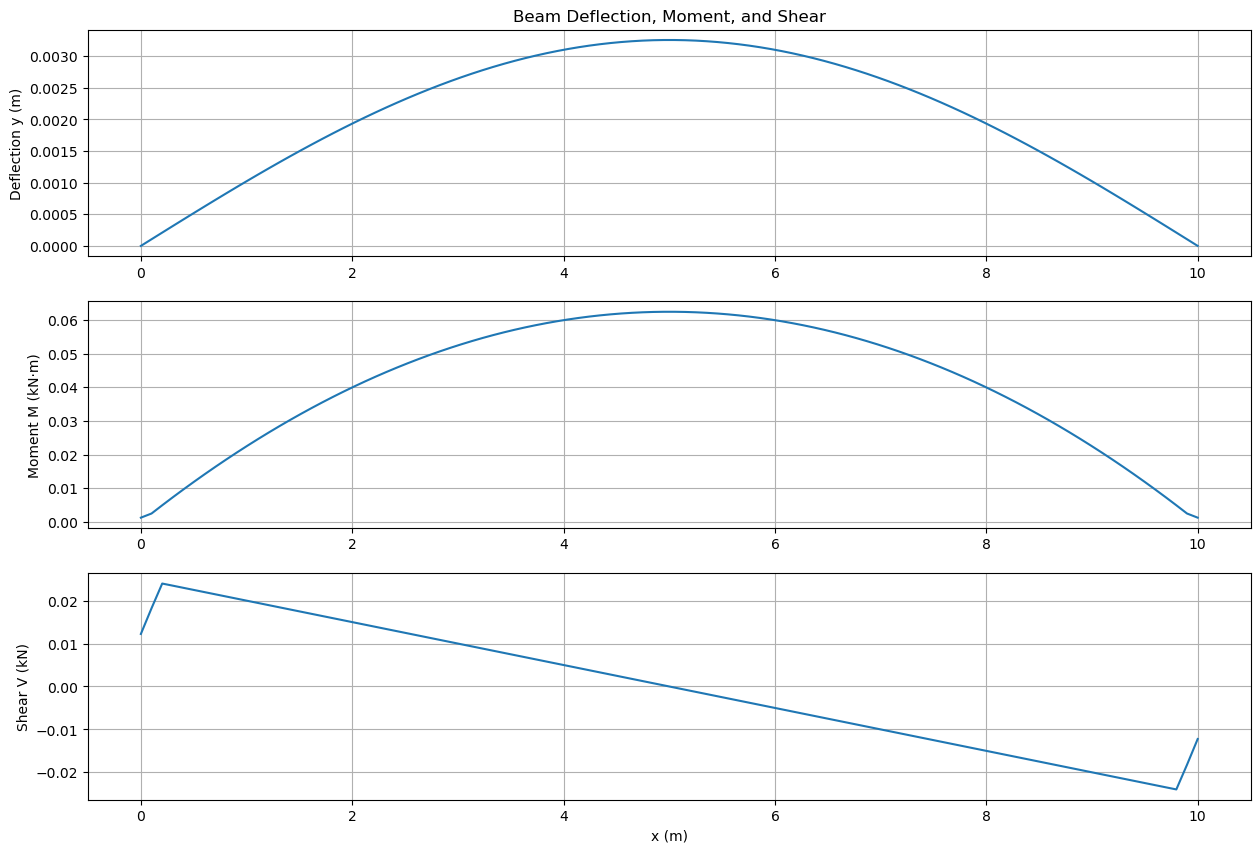

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
w = 5      # kN/m
L = 10     # m
E = 200e9  # Young's modulus in Pa
I = 1e-6   # Moment of inertia in m^4

# Your code here
def beam_deflection(x):
    return (w / (24 * E * I)) * x * (L**3 - 2*L*x**2 + x**3)

x_values = np.linspace(0, L, 100)
y_values = beam_deflection(x_values)

#def bending_moment(x):
    #return -E*I * (d**2*y) / (d*x**2)
#def shear_force(x):
    #return (d*M) / (d*x)

def bending_moment(x, y):
    #Computes bending moment M(x) = -E * I * d²y/dx²
    dy_dx = np.gradient(y, x)
    d2y_dx2 = np.gradient(dy_dx, x)
    M = -E * I * d2y_dx2
    return M

def shear_force(x, M):
    #Computes shear force V(x) = dM/dx
    V = np.gradient(M, x)
    return V

M_values = bending_moment(x_values, y_values)
V_values = shear_force(x_values, M_values)

# Plotting the functions
plt.figure(figsize=(15,10))

plt.subplot(3,1,1)
plt.plot(x_values, y_values)
plt.ylabel('Deflection y (m)')
plt.grid(True)
plt.title('Beam Deflection, Moment, and Shear')

plt.subplot(3,1,2)
plt.plot(x_values, M_values/1e3)
plt.ylabel('Moment M (kN·m)')
plt.grid(True)

plt.subplot(3,1,3)
plt.plot(x_values, V_values/1e3)
plt.ylabel('Shear V (kN)')
plt.xlabel('x (m)')
plt.grid(True)

plt.legend()
plt.show()



## 4. Ordinary Differential Equations - Initial Value Problems

This notebook introduces Ordinary Differential Equations (ODEs) with a focus on Initial Value Problems (IVPs). We will explore numerical methods such as Euler's Method and Runge-Kutta Methods with examples and visualizations.



### What is an ODE?

An Ordinary Differential Equation (ODE) is an equation involving a function and its derivatives.

### Initial Value Problem (IVP)
An IVP is an ODE along with a specified value at a starting point:

$$\frac{dy}{dx} = f(x, y), \quad y(x_0) = y_0$$



#### (a) Euler's Method

Algorithm:
1. Choose step size \( h \)
2. Iterate: \( y_{n+1} = y_n + h f(x_n, y_n) \)
3. Repeat for desired number of steps


#### Exercise
Use Euler's Method, solve dy/dx = exp(x) with the initial condition y(0)= 1

x	Euler_y	Exact_y
0.0 	 1.0 	 1.0
0.01 	 1.01 	 1.010050167084168
0.02 	 1.0201005016708418 	 1.0202013400267558
0.03 	 1.0303025150711094 	 1.030454533953517
0.04 	 1.0406070604106445 	 1.0408107741923882
0.05 	 1.0510151681525683 	 1.0512710963760241
0.060000000000000005 	 1.0615278791163285 	 1.0618365465453596
0.07 	 1.0721462445817822 	 1.0725081812542165
0.08 	 1.0828713263943244 	 1.0832870676749586
0.09 	 1.093704197071074 	 1.0941742837052104
0.09999999999999999 	 1.104645939908126 	 1.1051709180756477


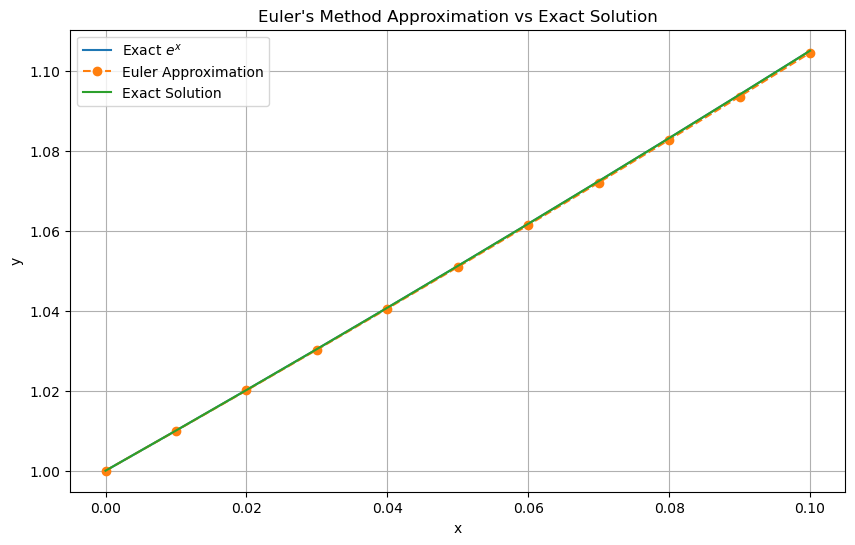

In [33]:
# Your code here
import numpy as np
import matplotlib.pyplot as plt

h = 0.01
step_number = 10

def f(x,y):
    return np.exp(x)

x0 = 0
y0 = 1
xs = [x0]
ys = [y0]

for n in range(step_number):
    y0 += h * f(x0, y0)
    x0 += h
    xs.append(x0)
    ys.append(y0)

xs = np.array(xs)
ys = np.array(ys)

exact_y = np.exp(xs)

print("x\tEuler_y\tExact_y")
for i in range(len(xs)):
    print(xs[i], "\t", ys[i], "\t", exact_y[i])

plt.figure(figsize=(10,6))
plt.plot(xs, exact_y, label='Exact $e^x$')
plt.plot(xs, ys, 'o--', label='Euler Approximation')
plt.plot(xs, np.exp(xs), label='Exact Solution')
plt.title("Euler's Method Approximation vs Exact Solution")
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()






#### (b) Runge-Kutta Method (RK4)

Algorithm:
1. Compute intermediate slopes:
   - \( k_1 = h f(x_n, y_n) \)
   - \( k_2 = h f(x_n + h/2, y_n + k_1/2) \)
   - \( k_3 = h f(x_n + h/2, y_n + k_2/2) \)
   - \( k_4 = h f(x_n + h, y_n + k_3) \)
2. Update: \( y_{n+1} = y_n + (k_1 + 2k_2 + 2k_3 + k_4)/6 \)


#### Exercise
Use RK4 Method, solve dy/dx = exp(x) with the initial condition y(0)= 1

x	RK4_y	Exact_y
0 	 1 	 1.0
0.01 	 1.01005 	 1.01005
0.02 	 1.020201 	 1.020201
0.03 	 1.030455 	 1.030455
0.04 	 1.040811 	 1.040811
0.05 	 1.051271 	 1.051271
0.06 	 1.061837 	 1.061837
0.07 	 1.072508 	 1.072508
0.08 	 1.083287 	 1.083287
0.09 	 1.094174 	 1.094174
0.1 	 1.105171 	 1.105171


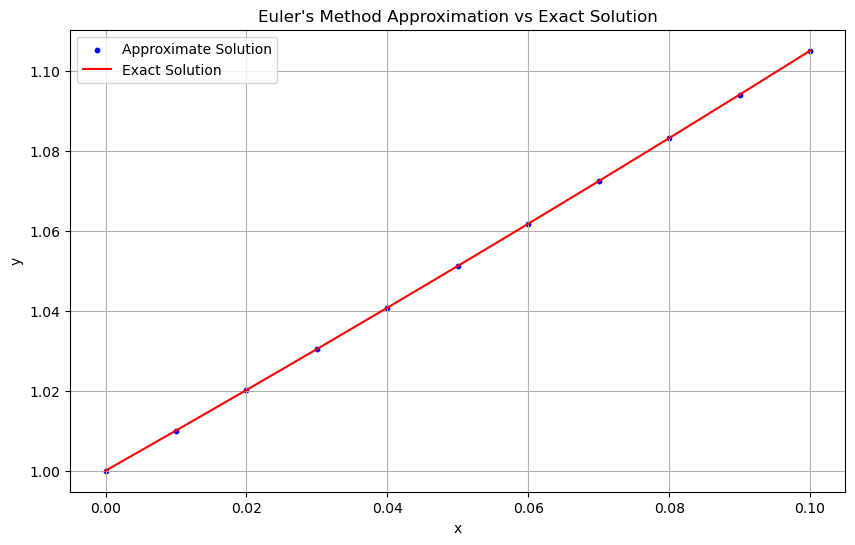

In [37]:
# Your code here
import numpy as np
import matplotlib.pyplot as plt

h = 0.01
step_number = 10

def f(x,y):
    return np.exp(x)

x0 = 0
y0 = 1
xs = [x0]
ys = [y0]

for n in range(step_number):
    K1 = h * f(x0, y0)
    K2 = h * f(x0 + h/2, y0 + K1/2)
    K3 = h * f(x0 + h/2, y0 + K2/2)
    K4 = h * f(x0 + h, y0 + K3)
    y0 += (1/6) * (K1 + 2*K2 + 2*K3 + K4)
    x0 += h
    xs.append(x0)
    ys.append(y0)

exact_y = np.exp(xs)

print("x\tRK4_y\tExact_y")
for i in range(len(xs)):
    print(round(xs[i], 3), "\t", round(ys[i], 6), "\t", round(exact_y[i], 6))


plt.figure(figsize=(10,6))
plt.scatter(xs, ys, color='blue', label='Approximate Solution', s=10)
plt.plot(xs, np.exp(xs), color='red', label='Exact Solution')
plt.title("Euler's Method Approximation vs Exact Solution")
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()